In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")
df


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [15]:
X = df[['Age', 'EstimatedSalary']].values

y = df["Purchased"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

clf = SVC(kernel='rbf', C=1, gamma=0.1)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0])

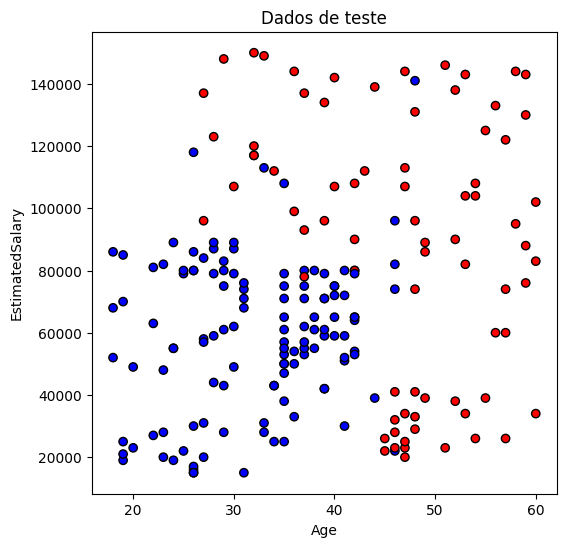

In [16]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='bwr', edgecolor='k')
plt.xlabel("Age")
plt.ylabel("EstimatedSalary")
plt.title("Dados de teste")
plt.show()

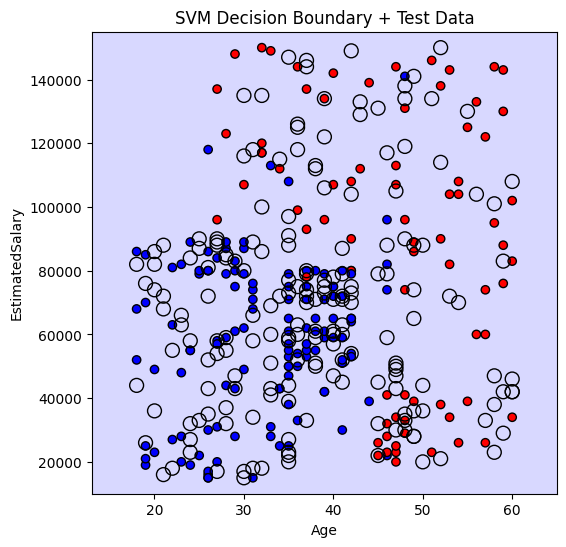

In [18]:
x_min, x_max = X[:,0].min()-5, X[:,0].max()+5
y_min, y_max = X[:,1].min()-5000, X[:,1].max()+5000
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

support_vectors = clf.support_vectors_


Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')   
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='bwr', edgecolor='k') 
plt.scatter(support_vectors[:,0], support_vectors[:,1], s=100, facecolors='none', edgecolors='k', label='Support Vectors')
plt.xlabel("Age")
plt.ylabel("EstimatedSalary")
plt.title("SVM Decision Boundary + Test Data")
plt.show()
